In [4]:
import os, yaml, sys
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import networkx as nx
from torchvision.datasets import ImageFolder
import random
ENV = os.getenv("MY_ENV", "dev")
with open("../../config.yaml", "r") as f:
    config = yaml.safe_load(f)
paths = config[ENV]["paths"]
sys.path.append(paths["src_path"])
sys.path.append(paths["useful_stuff_path"])
from useful_stuff.general_utils.utils import  print_wise, TimeSeries
from useful_stuff.general_utils.II import  dynInformationImbalance
from useful_stuff.image_processing.computational_models import  get_relevant_output_layers

#FIX IMPORTS
#  BrainAreas,load_img_natraster,
from project_specific_utils.dataloader import map_image_order_from_ann_to_monkey, BrainAreas, load_img_natraster
from II_analyses.static_dynII import init_static_dynII
# from general_utils.II import dynInformationImbalance, init_static_dynII

In [ ]:
from dataclasses import dataclass, field

@dataclass
class Cfg:
    monkey_name: str = 'three0  '
    date: str = '250313' # '250313' #  #  # # "230204"#'240816to26'
    brain_area: str = 'AIT'
    k=20
    new_fs: int = 100 # Hz
    model_name: str = 'vit_l_16'
    layer_name: str = 'blocks.16.mlp.fc2'
    signal_RDM_metric = "cosine_cnt"
    model_RDM_metric = "cosine_cnt"
    img_size: int = 384
    pooling: str = 'mean'
    pkg: str = 'timm'
    folder_name = 'talia_20each_tizi'
    subsamples_size = 200
    n_iterations = 20

cfg = Cfg()
layers = get_relevant_output_layers(cfg.model_name, cfg.pkg)
brain_areas = ['V1', 'V2', 'V3', 'PIT', 'CIT', 'AIT']

In [3]:
task_list = get_relevant_output_layers(cfg.model_name, cfg.pkg)
area_rasters = load_img_natraster(paths, cfg.monkey_name, cfg.date, new_fs=cfg.new_fs, brain_area=cfg.brain_area)

dataset = ImageFolder(
    root=f"{paths['livingstone_lab']}/Stimuli/{cfg.folder_name}/",
    is_valid_file=lambda x: not x.endswith("Thumbs.db"), 
    allow_empty=True, 
)
idx_ord = map_image_order_from_ann_to_monkey(paths, cfg.monkey_name, cfg.date, dataset)


In [6]:
layers_dict = {}
for l in layers:
    print_wise(f"starting layer {l}")
    feats_filename = f"{paths['data_path']}/models/{cfg.folder_name}_{cfg.model_name}_{cfg.img_size}_{l}_features_{cfg.pooling}pool.npz"
    features = np.load(feats_filename)["arr_0"][:, idx_ord]
    A2B_tot = []
    B2A_tot = []
    for i in range(cfg.n_iterations):
        subset = random.sample(range(len(idx_ord)), cfg.subsamples_size)
        subset_rasters = TimeSeries(area_rasters.get_array()[:,:,subset], cfg.new_fs)
        subset_features = features[:,subset]
        dyn_ii_obj = init_static_dynII(subset_rasters, cfg.signal_RDM_metric, cfg.model_RDM_metric, cfg.k)
        dyn_ii_obj.compute_RDM(subset_features, "model")
        dyn_ii_obj.compute_distance_ranks("model")
        dyn_ii = dyn_ii_obj.compute_both_static_dynII()
        A2B_tot.append(dyn_ii[0])
        B2A_tot.append(dyn_ii[1])

    A2B_tot = np.mean(A2B_tot, axis=0)
    B2A_tot = np.mean(B2A_tot, axis=0)
    layers_dict[f"{l}_A2B"] = A2B_tot
    layers_dict[f"{l}_B2A"] = B2A_tot




11:50:47 - starting layer blocks.0.mlp.fc2
11:50:49 - starting layer blocks.1.mlp.fc2
11:50:50 - starting layer blocks.2.mlp.fc2
11:50:52 - starting layer blocks.3.mlp.fc2
11:50:53 - starting layer blocks.4.mlp.fc2
11:50:54 - starting layer blocks.5.mlp.fc2
11:50:55 - starting layer blocks.6.mlp.fc2
11:50:56 - starting layer blocks.7.mlp.fc2
11:50:57 - starting layer blocks.8.mlp.fc2
11:50:59 - starting layer blocks.9.mlp.fc2
11:51:00 - starting layer blocks.10.mlp.fc2
11:51:01 - starting layer blocks.11.mlp.fc2
11:51:02 - starting layer blocks.12.mlp.fc2
11:51:03 - starting layer blocks.13.mlp.fc2
11:51:04 - starting layer blocks.14.mlp.fc2
11:51:05 - starting layer blocks.15.mlp.fc2
11:51:06 - starting layer blocks.16.mlp.fc2
11:51:08 - starting layer blocks.17.mlp.fc2
11:51:09 - starting layer blocks.18.mlp.fc2
11:51:10 - starting layer blocks.19.mlp.fc2
11:51:11 - starting layer blocks.20.mlp.fc2
11:51:12 - starting layer blocks.21.mlp.fc2
11:51:13 - starting layer blocks.22.mlp.fc

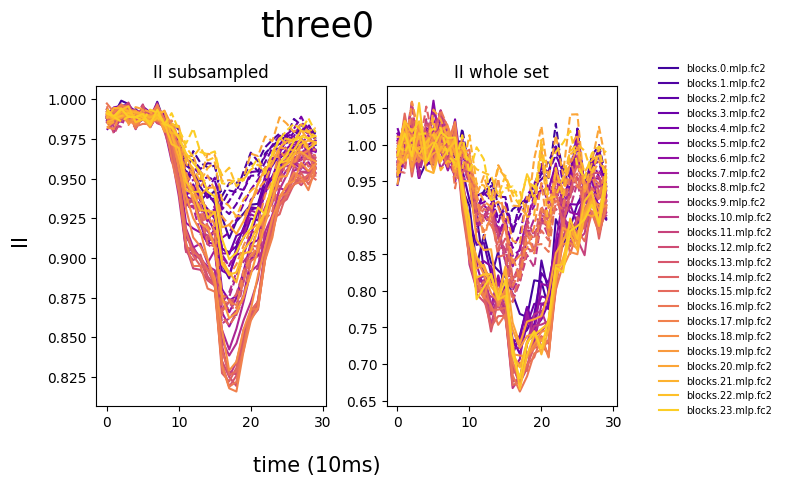

In [12]:
from useful_stuff.general_utils.plots import truncate_colormap
base_cmap = plt.cm.plasma
cmap = truncate_colormap(base_cmap, 0.10, 0.90)
fig, ax = plt.subplots(1, 2)
for i_col, l in enumerate(layers):
    color = cmap(i_col / (len(layers) - 1))
    ax[0].plot(layers_dict[f"{l}_A2B"], color=color, linestyle="--")
    ax[0].plot(layers_dict[f"{l}_B2A"], color=color, label=l)

for i_col, l in enumerate(layers):
    color = cmap(i_col / (len(layers) - 1))
    save_name_A2B = f"{paths['data_path']}/results/dynII_A2B_k{1}_{cfg.signal_RDM_metric}-{cfg.model_RDM_metric}_{cfg.monkey_name}_{cfg.date}_{cfg.brain_area}_{cfg.model_name}_{cfg.img_size}_{l}_{cfg.new_fs}Hz.npz"
    save_name_B2A = f"{paths['data_path']}/results/dynII_B2A_k{1}_{cfg.signal_RDM_metric}-{cfg.model_RDM_metric}_{cfg.monkey_name}_{cfg.date}_{cfg.brain_area}_{cfg.model_name}_{cfg.img_size}_{l}_{cfg.new_fs}Hz.npz"
    A2B = np.load(save_name_A2B)["arr_0"]
    B2A = np.load(save_name_B2A)["arr_0"]
    ax[1].plot(A2B, color=color, linestyle="--")
    ax[1].plot(B2A, color=color)

fig.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False, 
    fontsize=7
);

ax[0].set_title("II subsampled")
ax[1].set_title("II whole set")
fig.supylabel("II", fontsize=15)
fig.supxlabel("time (10ms)", fontsize=15)
fig.suptitle(f"{cfg.monkey_name}", fontsize=25)
plt.tight_layout()

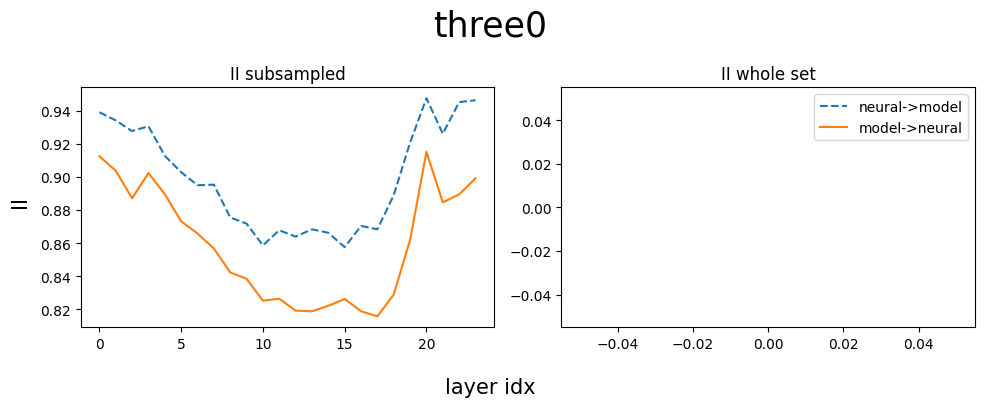

In [9]:
A2B_layers=[]
B2A_layers=[]
A2B_layers_gt=[]
B2A_layers_gt=[]
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
for i_col, l in enumerate(layers):
    A2B_layers.append(np.min(layers_dict[f"{l}_A2B"]))
    B2A_layers.append(np.min(layers_dict[f"{l}_B2A"]))
# for i_col, l in enumerate(layers):
#     save_name_A2B = f"{paths['livingstone_lab']}/tiziano/results/dynII_A2B_k{1}_{cfg.signal_RDM_metric}-{cfg.model_RDM_metric}_{cfg.monkey_name}_{cfg.date}_{cfg.brain_area}_{cfg.model_name}_{cfg.img_size}_{l}_{cfg.new_fs}Hz.npz"
#     save_name_B2A = f"{paths['livingstone_lab']}/tiziano/results/dynII_B2A_k{1}_{cfg.signal_RDM_metric}-{cfg.model_RDM_metric}_{cfg.monkey_name}_{cfg.date}_{cfg.brain_area}_{cfg.model_name}_{cfg.img_size}_{l}_{cfg.new_fs}Hz.npz"
#     A2B = np.load(save_name_A2B)["arr_0"]
#     B2A = np.load(save_name_B2A)["arr_0"]
#     A2B_layers_gt.append(np.min(A2B))
#     B2A_layers_gt.append(np.min(B2A))
ax[0].plot(A2B_layers, linestyle="--", label="neural->model") 
ax[0].plot(B2A_layers, label="model->neural") 
ax[1].plot(A2B_layers_gt, linestyle="--", label="neural->model") 
ax[1].plot(B2A_layers_gt, label="model->neural") 
ax[0].set_title("II subsampled")
ax[1].set_title("II whole set")
fig.supylabel("II", fontsize=15)
fig.supxlabel("layer idx", fontsize=15)
fig.suptitle(f"{cfg.monkey_name}", fontsize=25)
plt.legend()
plt.tight_layout()

Text(0.5, 0, 'layer idx')

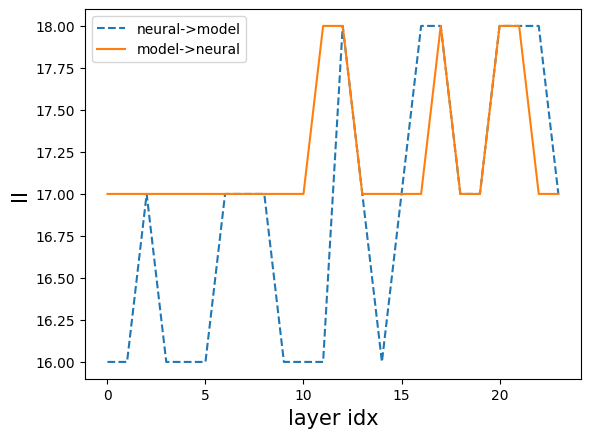

In [10]:
A2B_layers=[]
B2A_layers=[]
for i_col, l in enumerate(layers):
    A2B_layers.append(np.argmin(layers_dict[f"{l}_A2B"]))
    B2A_layers.append(np.argmin(layers_dict[f"{l}_B2A"]))
plt.plot(A2B_layers, linestyle="--", label="neural->model") 
plt.plot(B2A_layers, label="model->neural") 
plt.legend()
plt.ylabel("II", fontsize=15)
plt.xlabel("layer idx", fontsize=15)